# Lab 14 -- Transfer Learning

Esraaj Sarkar Gupta on the 10th of May

In [1]:
# ---- Imports ---- #

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from sklearn.svm import SVC
import tensorflow as tf

print(f"Completed all imports sucessfully...")

2026-05-10 01:00:06.101852: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-10 01:00:06.640013: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-10 01:00:10.313667: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Completed all imports sucessfully...


Found 178 files belonging to 7 classes.
Using 143 files for training.
Found 178 files belonging to 7 classes.
Using 35 files for validation.


2026-05-10 01:04:34.675238: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


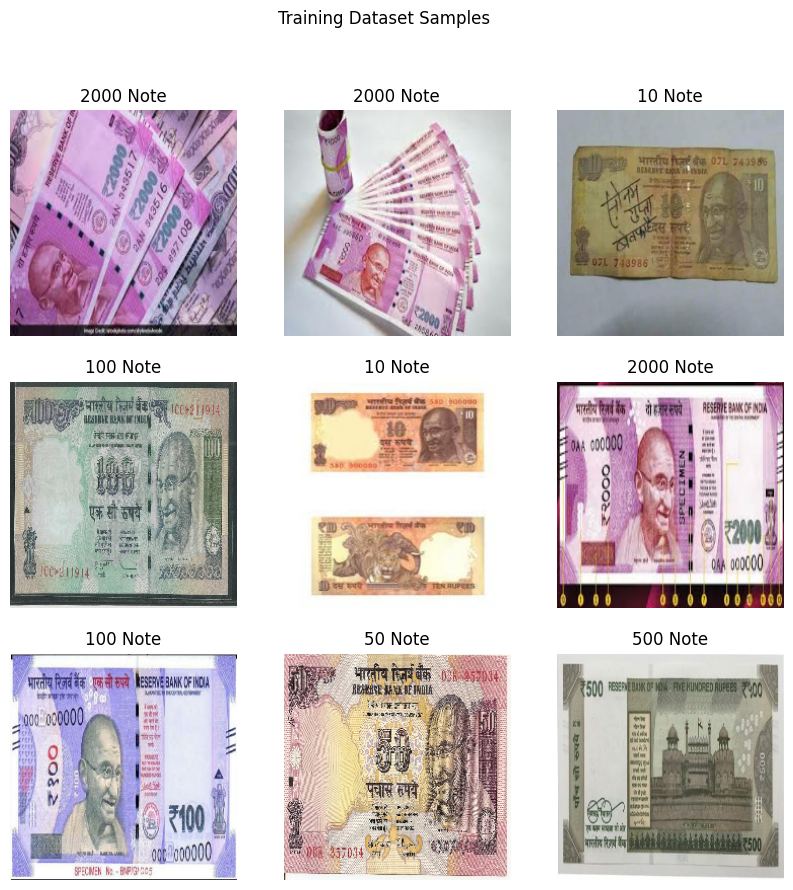

In [5]:
# ---- Data ---- #

data_dir : Path = Path("IndianCurrencyNotesDataset/AllImages")

# -- 80% Training Data Split -- #
train_ds = image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "training",
    seed = 194, # days since a special day
    image_size = (224,224),
    batch_size= 32
)

# -- Validation Split -- #
val_ds = image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "validation",
    seed = 194,
    image_size = (224,224),
    batch_size = 32
)

class_names = train_ds.class_names

# Gander at a few samples with me
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Training Dataset Samples")
plt.show()


# --- Augmentation --- #
# Only to be applied to the training data
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.2),
])

In [6]:
# ---- Load ResNet50 ---- #
# We extract features
# The fully connected classification layer is removed

# -- Build Base Model -- #
base_model = ResNet50(
    weights = 'imagenet',
    include_top = False,        # As mentioned, the fully connected classification layer is removed
    pooling = 'avg',            # Average Pooling
    input_shape=(224, 224, 3)   # RBG
)

# -- Extract Features -- #
def extract_features(dataset, augment=False):
    all_features : list = list([])
    all_labels :list = list([])

    for images, labels in dataset:
        # Augment?
        if augment:
            images = data_augmentation(images)

        # Apply ResNet50 specific preprocessing
        preprocessed_images = tf.keras.applications.resnet50.preprocess_input(images)
        features = base_model.predict(
            preprocessed_images, 
            verbose = 0 # If you make too much noise then the monster under the bed will get ya!
        )

        all_features.append(features)
        all_labels.append(labels.numpy())

    return np.vstack(all_features), np.concatenate(all_labels)

print("[PROGRESS] Extracting features from training set...")
X_train, y_train = extract_features(train_ds, augment = True) # Only augment the training dataset

print("[PROGRESS] Extracting features from validation set...")
X_val, y_val = extract_features(val_ds, augment = False)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
[PROGRESS] Extracting features from training set...
[PROGRESS] Extracting features from validation set...


2026-05-10 01:12:37.480668: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
# ---- SVM Classifier ---- #
# We need a final classifier

print("[PROGRESS] Training SVM Classifier...")
svm_classifier = SVC(kernel='linear', random_state=42) 
svm_classifier.fit(X_train, y_train)
print("[OK] Training complete.")

print("[PROGRESS] Making predictions...")
y_pred = svm_classifier.predict(X_val)
print("[OK] Predictions complete.")

[PROGRESS] Training SVM Classifier...
[OK] Training complete.
[PROGRESS] Making predictions...
[OK] Predictions complete.


Accuracy: 0.7714
Weighted F1-Score: 0.7791


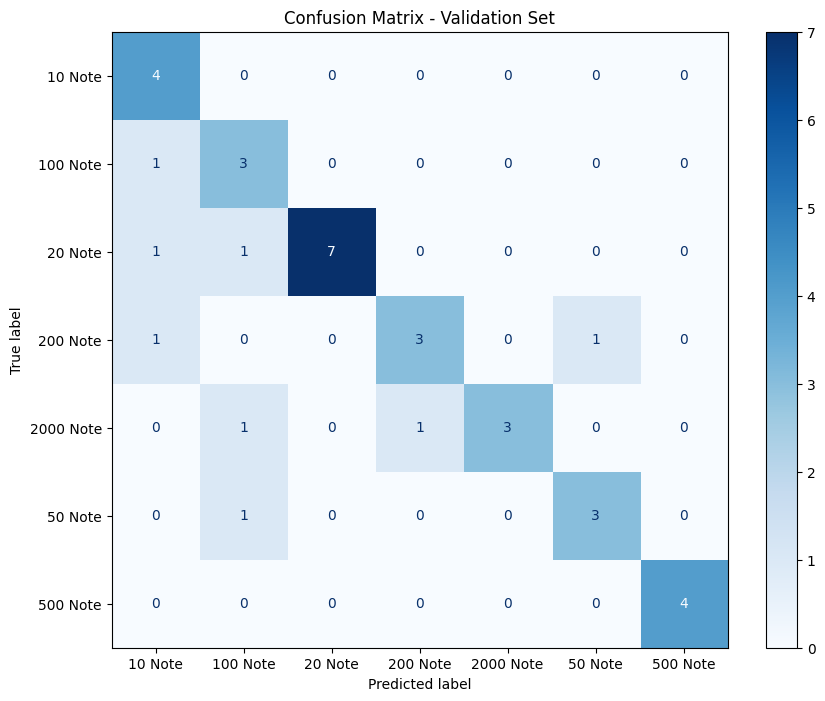

In [8]:
# ---- Performance Metrics ---- #
# So how did we do?

accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average='weighted')

# Report to the boss
print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")

# -- Confusion Matrix -- #
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix - Validation Set")

plt.show()

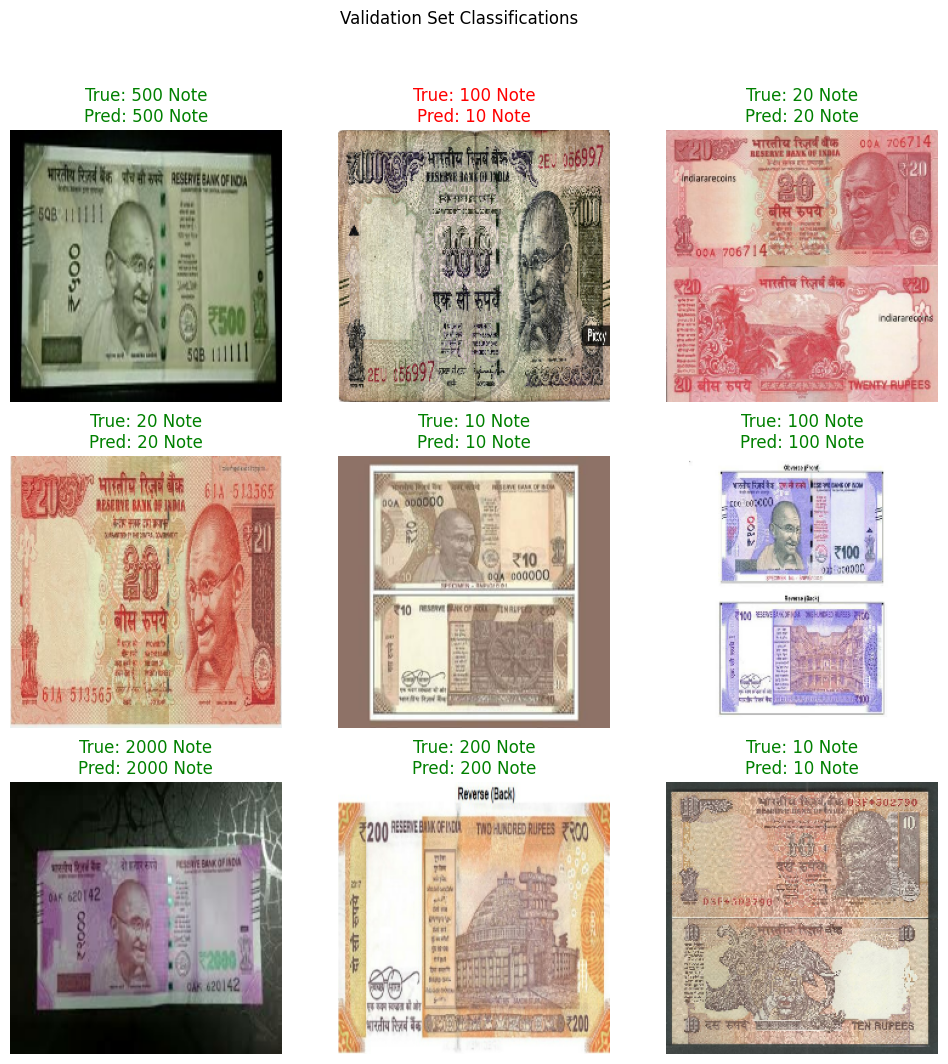

In [10]:
# ---- Display Classification ---- #

for images, labels in val_ds.take(1): # Grap the first batch of images
    # Preprocess
    preprocessed_images = tf.keras.applications.resnet50.preprocess_input(images)

    # Extract features and predict
    features = base_model.predict(preprocessed_images, verbose=0)
    predictions = svm_classifier.predict(features)
    
    # Plot Results
    plt.figure(figsize=(12, 12))

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i]]
        pred_label = class_names[predictions[i]]

        color = 'green' if (true_label == pred_label) else 'red' # Make the mistakes easier to spot

        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
        plt.axis("off") # No graphs
    plt.suptitle("Validation Set Classifications")

    plt.show()

# Report

#### Question 1

The main innovation in ResNet was the introdction of "skip connections", also known as residual blocks. This allosed gradients to flow directly through the network during backpropagation, effectively solving the <i>vanishing gradient problem</i>, and allowing the training of networks with hundreds of layers.
<br><br>
On the other hand, GoogLeNet introduced the "inception module" which performs multiple convolutions with different filter sizes (such as 1x1, 3x3, 5x5) and max pooling in parallel. It alo used 1x1 convolutions heavily to reduce dimensionality and mitigate computational bottlenecks before performing the more expensive convolutions.

#### Question 2

Transfer learning is necessary when we lack sufficient data (which I do) to train a deep neural network from scratch without overfitting. It may also be used when lacking hardware powerful enough to carry out the computational expense training a deep neural network may demand (for example, I am running all of this on on iRISx graphics card). This can be done since the model has already learned generalized feature representations (such as edges, shapes and textures) from massive datasets. 

#### Question 3
Upsampling helps if a target dataset is imbalanced. Without upsampling, a classifier like SVM will become biased towards the majority class. Upsampling minority classes ensures that the model learns equally robust decision boundaries for all the classes.

#### Question 4
There are some limitations of tranfer learning. For one, there are fixed input constrains -- pretrained models will require inputs resized to specific dimensions (such as 224x224 px). This can distort aspect ratios, or destroy the finer details in the input necessary for classification. There is also the possibility of a Negative Transfer, where the original source data may be very different from the target domain. This can render the transfer features irrelevant. This may lead to worse performance than training from scratch.

#### Question 5

There are two approaches to Transfer Learning. The first method we will talk about is called <i>feature extraction</i> -- the weights and biases of the pre-trained network is frozen, and the netwrok acts solely as a feature extractor. A new classifier (such as SVM) is trained from scratch on top of these extracted features. The second method is called <i>fine-tuning</i>. In fine-tuning, the weights of the pre-trained model are initialized, but some (usually of the deepler layers') or all of the networks layers are unfrozen and trained jointly with the new classifer to slightly adjust the weights to the specific target domain.  